# Detection pipeline

**For real data:** edit `~/.piepy/config.json` so `paths.presentation` / `paths.analysis` point at your dirs. (Real sessions need their full artifacts — e.g. opto-pattern images for opto sessions — or parsing will raise.)

In [7]:
import os, glob
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from piepy.core.config import config
from piepy.core.registry import get_session_class
from piepy.core.hub import Hub
from piepy.simulations.session import simulate_session
from piepy.stats import aggregate, Rate, Median
from piepy.fitting import fit

pres = config.paths["presentation"][0]
print('presentation dir:', pres)

presentation dir: /Users/kaan/data/presentation


## Find sessions

In [8]:
candidates = sorted(glob.glob(os.path.join(pres, "*detect*")))
print(f"found {len(candidates)} candidate detection session(s)")
for c in candidates[:5]:
    print(' ', os.path.basename(c))

found 329 candidate detection session(s)
  220504_KC139_detect_V1_opto120__no_cam_KC_skip
  220510_KC139_detect_opto080_V1__no_cam_KC_skip
  220510_KC139_detect_opto120_V1__no_cam_KC_skip
  220510_KC139_detect_opto160_V1__no_cam_KC_skip
  220512_KC139_detect_opto080_V1__no_cam_KC_skip


## Parse a single session
Builds the Session, parses each run, and stacks them onto one session clock. Wrapped defensively so a real-data hiccup prints a clear error instead of aborting.

In [11]:
df = None
if candidates:
    name = os.path.basename(candidates[0])

    sess = get_session_class("detection")(name, load_flag=False)
    df = sess.concatenate_runs("detection")
    print(name, "->", df.shape)



ImportError: cannot import name '__version__' from 'piepy' (unknown location)

## Cohort across many sessions (`Hub`)
`Hub` runs each session in parallel and stacks them into one cohort table. It already isolates per-session failures (a bad session warns and is skipped).

In [10]:
cohort = None
if candidates:
    try:
        hub = Hub("detection")
        hub.initialize([os.path.basename(c) for c in candidates], load_sessions=False)
        cohort = hub.data
        print('cohort:', None if cohort is None else cohort.shape)
    except Exception as e:
        print("Hub gather failed:", type(e).__name__, e)

Hub gather failed: ImportError cannot import name '__version__' from 'piepy' (unknown location)


## Psychometric: P(hit) vs signed contrast
Aggregate to a tidy per-condition estimate (Wilson CI), then fit a logistic.

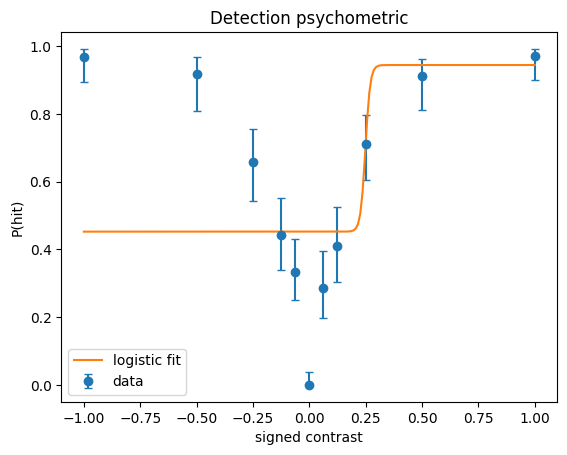

In [5]:
data = df if df is not None else simulate_session(
    paradigm="detection", n_trials=900, early_rate=0.1, seed=0)

# P(hit) vs signed contrast, excluding early (no-stimulus) trials
psy = aggregate(
    data.filter(pl.col("outcome") != "early"),
    group=["signed_contrast"],
    metrics=[Rate("outcome", success="hit")],
)
x, y = psy["signed_contrast"].to_numpy(), psy["value"].to_numpy()
n = psy["n"].to_numpy()
res = fit("logistic", x, y, n=n)

xx = np.linspace(x.min(), x.max(), 200)
plt.errorbar(x, y, yerr=[y - psy['ci_low'].to_numpy(), psy['ci_high'].to_numpy() - y],
             fmt="o", capsize=3, label="data")
plt.plot(xx, res.predict(xx), "-", label="logistic fit")
plt.xlabel("signed contrast"); plt.ylabel("P(hit)")
plt.title("Detection psychometric"); plt.legend(); plt.show()

## Reaction time vs signed contrast
Same `aggregate` API, a `Median` metric with its order-statistic CI.

In [6]:
rt = aggregate(data.filter(pl.col("outcome") == "hit"), group=["signed_contrast"], metrics=[Median("response_time")])
rt

signed_contrast,metric,value,ci_low,ci_high,n
f64,str,f64,f64,f64,i64
-1.0,"""median[response_time]""",287.020356,250.726351,335.431166,63
-0.5,"""median[response_time]""",271.740997,233.791906,299.403206,45
-0.25,"""median[response_time]""",261.929508,248.689239,283.739677,48
-0.125,"""median[response_time]""",284.547863,251.969271,320.40172,35
-0.0625,"""median[response_time]""",307.808726,217.089231,369.408449,34
0.0625,"""median[response_time]""",259.345557,215.352517,337.409982,22
0.125,"""median[response_time]""",274.629929,238.366199,316.502246,30
0.25,"""median[response_time]""",291.590302,242.984815,336.933233,59
0.5,"""median[response_time]""",255.066016,235.163007,308.213938,52
